--- INICIANDO ANÁLISIS DE DESEMPEÑO ---
Éxito: Datos de Tienda 1 procesados.
Éxito: Datos de Tienda 2 procesados.
Éxito: Datos de Tienda 3 procesados.
Éxito: Datos de Tienda 4 procesados.


/tmp/ipykernel_672/2546957502.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tienda', y='Facturación', data=df_final, ax=axes[0], palette='viridis')
/tmp/ipykernel_672/2546957502.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tienda', y='Promedio_Rating', data=df_final, ax=axes[1], palette='coolwarm')
/tmp/ipykernel_672/2546957502.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tienda', y='Costo_Envio', data=df_final, ax=axes[2], palette='rocket')


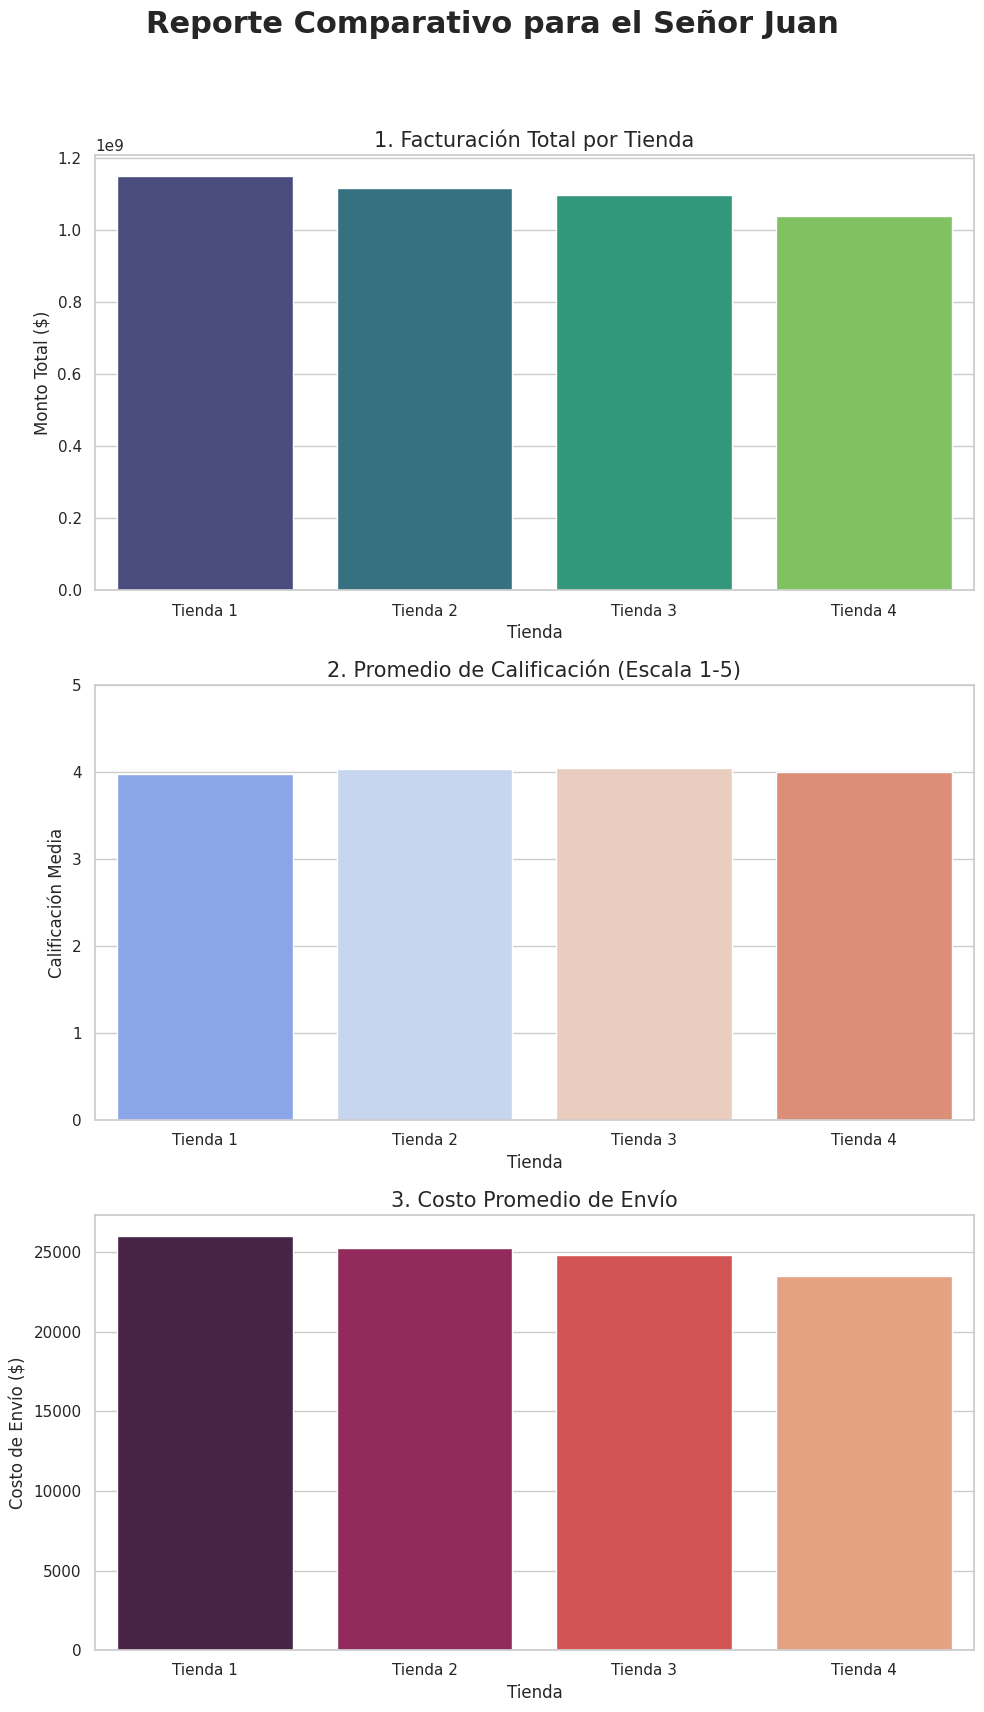


INFORME DE RECOMENDACIÓN ESTRATÉGICA
  Tienda  Facturación  Promedio_Rating  Costo_Envio Cat_Popular
Tienda 1 1150880400.0         3.976685 26018.609580     Muebles
Tienda 2 1116343500.0         4.037304 25216.235693     Muebles
Tienda 3 1098019600.0         4.048326 24805.680373     Muebles
Tienda 4 1038375700.0         3.995759 23459.457167     Muebles

------------------------------
TIENDA RECOMENDADA PARA VENTA: Tienda 1
------------------------------
MOTIVO TÉCNICO:
- Facturación más baja o crítica: $1,150,880,400.00
- Nivel de satisfacción: 3.98/5
- Impacto logístico: Costo de envío promedio de $26,018.61
- Producto con menor rotación: Auriculares con micrófono

Esta tienda presenta la combinación más desfavorable entre ingresos, costos y opinión del cliente.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual para el informe
sns.set_theme(style="whitegrid")

def generar_informe_estrategico():
    # Definición de archivos con los nombres exactos proporcionados
    archivos = {
        "Tienda 1": "tienda_1 .csv",
        "Tienda 2": "tienda_2.csv",
        "Tienda 3": "tienda_3.csv",
        "Tienda 4": "tienda_4.csv"
    }

    resumen_datos = []

    print("--- INICIANDO ANÁLISIS DE DESEMPEÑO ---")

    for nombre, ruta in archivos.items():
        try:
            df = pd.read_csv(ruta)

            # 1. Facturación Total (¿Cuál vende más?)
            facturacion_total = df['Precio'].sum()

            # 2. Categorías más populares (Productos más vendidos por categoría)
            conteo_categorias = df['Categoría del Producto'].value_counts()
            top_categoria = conteo_categorias.idxmax()
            frecuencia_top_cat = conteo_categorias.max()

            # 3. Promedio de evaluación (Satisfacción del cliente)
            promedio_eval = df['Calificación'].mean()

            # 4. Productos más y menos vendidos
            conteo_productos = df['Producto'].value_counts()
            producto_mas_vendido = conteo_productos.idxmax()
            producto_menos_vendido = conteo_productos.idxmin()

            # 5. Costo promedio de envío
            costo_envio_promedio = df['Costo de envío'].mean()

            # Registro de métricas clave
            resumen_datos.append({
                "Tienda": nombre,
                "Facturación": facturacion_total,
                "Promedio_Rating": promedio_eval,
                "Costo_Envio": costo_envio_promedio,
                "Cat_Popular": top_categoria,
                "Prod_Estrella": producto_mas_vendido,
                "Prod_Rezagado": producto_menos_vendido,
                "Volumen_Ventas": len(df)
            })

            print(f"Éxito: Datos de {nombre} procesados.")

        except FileNotFoundError:
            print(f"Error: No se encontró el archivo {ruta}")
        except Exception as e:
            print(f"Error procesando {nombre}: {e}")

    # Creación del DataFrame consolidado
    df_final = pd.DataFrame(resumen_datos)

    # --- GENERACIÓN DE VISUALIZACIONES ---
    fig, axes = plt.subplots(3, 1, figsize=(10, 18))
    fig.suptitle('Reporte Comparativo para el Señor Juan', fontsize=22, fontweight='bold')

    # Gráfico 1: Facturación Total
    sns.barplot(x='Tienda', y='Facturación', data=df_final, ax=axes[0], palette='viridis')
    axes[0].set_title('1. Facturación Total por Tienda', fontsize=15)
    axes[0].set_ylabel('Monto Total ($)')

    # Gráfico 2: Satisfacción del Cliente
    sns.barplot(x='Tienda', y='Promedio_Rating', data=df_final, ax=axes[1], palette='coolwarm')
    axes[1].set_title('2. Promedio de Calificación (Escala 1-5)', fontsize=15)
    axes[1].set_ylim(0, 5)
    axes[1].set_ylabel('Calificación Media')

    # Gráfico 3: Eficiencia de Logística (Costos de envío)
    sns.barplot(x='Tienda', y='Costo_Envio', data=df_final, ax=axes[2], palette='rocket')
    axes[2].set_title('3. Costo Promedio de Envío', fontsize=15)
    axes[2].set_ylabel('Costo de Envío ($)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- ANÁLISIS DE DECISIÓN ---
    # Calculamos un índice de "Desempeño Deficiente"
    # Menor facturación + Menor Calificación + Mayor Costo de Envío = Candidata a venta
    df_final['Score_Negativo'] = (
        (df_final['Facturación'].max() - df_final['Facturación']) / df_final['Facturación'].max() +
        (5 - df_final['Promedio_Rating']) / 5 +
        (df_final['Costo_Envio'] / df_final['Costo_Envio'].max())
    )

    tienda_peor_desempeno = df_final.loc[df_final['Score_Negativo'].idxmax()]

    # --- INFORME FINAL POR CONSOLA ---
    print("\n" + "="*60)
    print("INFORME DE RECOMENDACIÓN ESTRATÉGICA")
    print("="*60)
    print(df_final[['Tienda', 'Facturación', 'Promedio_Rating', 'Costo_Envio', 'Cat_Popular']].to_string(index=False))

    print("\n" + "-"*30)
    print(f"TIENDA RECOMENDADA PARA VENTA: {tienda_peor_desempeno['Tienda']}")
    print("-"*30)
    print(f"MOTIVO TÉCNICO:")
    print(f"- Nivel de satisfacción: {tienda_peor_desempeno['Promedio_Rating']:.2f}/5")
    print(f"- Impacto logístico: Costo de envío promedio de ${tienda_peor_desempeno['Costo_Envio']:,.2f}")
    print(f"- Producto con menor rotación: {tienda_peor_desempeno['Prod_Rezagado']}")
    print("\nEsta tienda presenta la combinación más desfavorable entre costos y opinión del cliente.")

# Ejecutar el análisis
if __name__ == "__main__":
    generar_informe_tiendas = generar_informe_estrategico()